In [1]:
import glob, os, re
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

# ============================ CONFIG ============================
DATA_DIR   = "nba_data"                      # folder holding the per-season CSVs
FILE_GLOB  = "nba_fantasy_*.csv"

# Your stat columns, in the FIXED display order you want (keep this order
# stable across runs so matrices are comparable year to year).
#   'G' = games played
# STAT_COLUMNS = ["PTS", "TRB", "AST", "STL", "BLK"]
STAT_COLUMNS = ["TRB", "AST", "STL", "BLK", "PTS"]

# Of the stat columns above, which are per-game counting stats that should
# be put on a per-36-minute basis:  stat_per36 = stat_per_game / MP * 36
# (MP and the counting stats here are already per-game averages, so the
#  "per game" cancels and this yields a clean per-36 number.)
RESCALE     = ["PTS", "TRB", "AST", "STL","BLK"]   # G is left as-is
MINUTES_COL = "MP"
PER_MINUTES = 36

# Salary is ALWAYS appended as the final column and relabeled. It is a level,
# not a per-minute rate, so it is never rescaled.
APPEND_SALARY = True
SALARY_SRC    = "PREDICTED_SALARY"
SALARY_LABEL  = "salary"

CORR_METHOD = "spearman"              # you asked for Spearman

# A pair is "sign-flipping" if it has at least one correlation above
# +SIGN_FLIP_THRESHOLD and at least one below -SIGN_FLIP_THRESHOLD across
# seasons. 0.0 = pure sign flip. Raise it (e.g. 0.10) to demand a *material*
# flip and ignore pairs that merely jitter across zero.
SIGN_FLIP_THRESHOLD = 0.0
# ===============================================================

# Effective column list used everywhere downstream: stats, then salary last.
COLUMNS = STAT_COLUMNS + ([SALARY_LABEL] if APPEND_SALARY else [])

def season_from_name(path):
    m = re.search(r"(\d{4})", os.path.basename(path))
    return int(m.group(1)) if m else None


def load_and_prepare(path):
    """Load one file, select configured columns, apply per-36 rescaling,
    and append salary (relabeled) as the final column."""
    src = list(dict.fromkeys(STAT_COLUMNS + [MINUTES_COL]
                             + ([SALARY_SRC] if APPEND_SALARY else [])))
    df = pd.read_csv(path, usecols=src)
    for c in RESCALE:
        df[c] = df[c] / df[MINUTES_COL] * PER_MINUTES
    out = df[STAT_COLUMNS].copy()
    if APPEND_SALARY:
        out[SALARY_LABEL] = df[SALARY_SRC]          # level, not rescaled
    return out[COLUMNS]                             # fixed column order


def per_file_corr_matrices():
    files = sorted(glob.glob(os.path.join(DATA_DIR, FILE_GLOB)))
    if not files:
        raise SystemExit(f"No files matched {FILE_GLOB} in {DATA_DIR!r}")
    seasons, mats = [], []
    for f in files:
        df = load_and_prepare(f)
        c = df.corr(method=CORR_METHOD).reindex(index=COLUMNS, columns=COLUMNS)
        mats.append(c.values)
        seasons.append(season_from_name(f))
    return files, seasons, np.stack(mats)           # stack: (n_files, k, k)


def tidy_pairwise(seasons, stack):
    rows = []
    for s_idx, season in enumerate(seasons):
        for i, j in combinations(range(len(COLUMNS)), 2):
            rows.append({"season": season,
                         "pair": f"{COLUMNS[i]}-{COLUMNS[j]}",
                         "r": stack[s_idx, i, j]})
    return pd.DataFrame(rows)


files, seasons, stack = per_file_corr_matrices()
k        = len(COLUMNS)
mean_mat = np.nanmean(stack, axis=0)
tidy     = tidy_pairwise(seasons, stack)

# sign-flip detection
thr = SIGN_FLIP_THRESHOLD
flips = {(COLUMNS[i], COLUMNS[j])
         for i, j in combinations(range(k), 2)
         if (stack[:, i, j] > thr).any() and (stack[:, i, j] < -thr).any()}

print(f"Loaded {len(files)} files | seasons {min(seasons)}-{max(seasons)} "
      f"| columns {COLUMNS}")
print(f"Rescaled per-{PER_MINUTES}: {RESCALE} | method: {CORR_METHOD}")

Loaded 17 files | seasons 2000-2016 | columns ['TRB', 'AST', 'STL', 'BLK', 'PTS', 'salary']
Rescaled per-36: ['PTS', 'TRB', 'AST', 'STL', 'BLK'] | method: spearman


In [2]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
import glob, re
from itertools import combinations
from collections import Counter

FRONT_GLOB = 'data/game_data/pf_block_2_trial_*.csv'   # one front per year; year parsed from the filename
objectives = []                          # [] = take the columns from the files' header
CHUNK = 2000                             # rows per block in the pairwise scan
WIN_THRESHOLD = 0.5                      # a 'winning point' beats at least this share of the field
ACCENT = '#3B6EA5'

files = glob.glob(FRONT_GLOB)
year_files = sorted((int(re.search(r'_(\d{4})\.csv$', f).group(1)), f) for f in files)
years = [y for y, _ in year_files]
assert years, f"no files matched {FRONT_GLOB!r}"

if not objectives:
    objectives = list(pd.read_csv(year_files[0][1], nrows=0).columns)
for y, f in year_files:
    cols = list(pd.read_csv(f, nrows=0).columns)
    assert cols == objectives, f"{f} has {cols}, expected {objectives}"

D = len(objectives); m = D // 2 + 1
print(f"{len(year_files)} fronts, years {years[0]}-{years[-1]}")
print(f"objectives ({D}): {objectives}")
print(f"m = {m}   |   minimal coalitions = C({D},{m}) = {len(list(combinations(range(D), m)))}")

def analyze(X):
    N, D = X.shape
    m = D // 2 + 1
    majority_sizes = list(range(m, D))
    coals = list(combinations(range(D), m))
    masks = [sum(1 << d for d in c) for c in coals]
    weights = (1 << np.arange(D)).astype(np.int64)
    bmdt = np.int16 if D <= 15 else np.int64

    bit_counts = np.zeros(1 << D, dtype=np.int64); total = 0
    win_count  = np.zeros(N, dtype=np.int64)
    sweep      = np.zeros((len(coals), N), dtype=np.int64)
    for s in range(0, N, CHUNK):
        e = min(s + CHUNK, N); b = e - s
        wins_b = np.zeros((b, N), np.int16); bm = np.zeros((b, N), bmdt)
        for d in range(D):
            gd = X[s:e, d][:, None] > X[:, d][None, :]
            wins_b += gd; bm += gd * bmdt(weights[d])
        loc, glob = np.arange(b), np.arange(s, e)
        wins_b[loc, glob] = 0; bm[loc, glob] = 0
        maj = np.isin(wins_b, majority_sizes); maj[loc, glob] = False
        win_count[s:e] = maj.sum(1); total += int(maj.sum())
        bit_counts += np.bincount(bm[maj], minlength=1 << D)
        for ci, mask in enumerate(masks):
            sweep[ci, s:e] = ((bm & mask) == mask).sum(1)
        del wins_b, bm, maj

    cov = Counter()
    for W in np.flatnonzero(bit_counts):
        c = int(bit_counts[W]); members = [d for d in range(D) if (W >> d) & 1]
        for sub in combinations(members, m):
            cov[sub] += c
    coverage = {sub: (cov.get(sub, 0) / total if total else 0.0) for sub in coals}
    win_rate = win_count / (N - 1)
    return coals, coverage, sweep, win_rate

cov_by_year, mean_by_year, med_by_year = {}, {}, {}
p90_by_year, max_by_year, cnt_by_year = {}, {}, {}
for yr, f in year_files:
    X = pd.read_csv(f)[objectives].to_numpy(dtype=float)
    coals, coverage, sweep, win_rate = analyze(X)
    dom = sweep.argmax(0)
    winner = win_rate >= WIN_THRESHOLD
    cov_by_year[yr] = {c: coverage[c] for c in coals}
    md_, mdd_, p9_, mx_, cd_ = {}, {}, {}, {}, {}
    for i, c in enumerate(coals):
        grp = win_rate[winner & (dom == i)]
        md_[c]  = float(grp.mean())             if grp.size else np.nan
        mdd_[c] = float(np.median(grp))         if grp.size else np.nan
        p9_[c]  = float(np.percentile(grp, 90)) if grp.size else np.nan
        mx_[c]  = float(grp.max())              if grp.size else np.nan
        cd_[c]  = int(grp.size)
    mean_by_year[yr], med_by_year[yr] = md_, mdd_
    p90_by_year[yr],  max_by_year[yr], cnt_by_year[yr] = p9_, mx_, cd_
    print(f"  {yr}: {X.shape[0]:>6,} points  |  winning points (>= {WIN_THRESHOLD:.0%}): {int(winner.sum()):,}")

def to_df(d):
    df = pd.DataFrame(d)
    df.index = ['+'.join(objectives[k] for k in sub) for sub in df.index]
    return df[sorted(df.columns)]

coverage_summary = to_df(cov_by_year)
meanwr_summary   = to_df(mean_by_year)
medianwr_summary = to_df(med_by_year)
p90wr_summary    = to_df(p90_by_year)
maxwr_summary    = to_df(max_by_year)
count_summary    = to_df(cnt_by_year)
meanwr_summary.round(3)

17 fronts, years 2000-2016
objectives (5): ['REB', 'AST', 'STL', 'BLK', 'PTS']
m = 3   |   minimal coalitions = C(5,3) = 10
  2000: 11,266 points  |  winning points (>= 50%): 6,149
  2001:  9,367 points  |  winning points (>= 50%): 5,081
  2002: 12,189 points  |  winning points (>= 50%): 6,630
  2003:  8,126 points  |  winning points (>= 50%): 4,338
  2004: 11,264 points  |  winning points (>= 50%): 5,990
  2005:  8,137 points  |  winning points (>= 50%): 4,346
  2006:  7,463 points  |  winning points (>= 50%): 3,980
  2007:  6,649 points  |  winning points (>= 50%): 3,535
  2008:  7,158 points  |  winning points (>= 50%): 3,863
  2009:  6,542 points  |  winning points (>= 50%): 3,433
  2010:  7,749 points  |  winning points (>= 50%): 4,051
  2011:  9,263 points  |  winning points (>= 50%): 4,800
  2012:  8,317 points  |  winning points (>= 50%): 4,456
  2013:  7,973 points  |  winning points (>= 50%): 4,148
  2014:  5,811 points  |  winning points (>= 50%): 3,115
  2015:  5,924 points

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
REB+AST+STL,0.564,0.560,0.563,0.552,0.534,0.520,0.531,0.538,0.568,0.539,0.540,0.560,0.559,0.529,0.558,NaN,0.557
REB+AST+BLK,0.546,0.557,0.543,0.524,0.528,0.544,0.539,0.528,0.559,0.527,0.528,0.510,NaN,NaN,0.513,0.545,0.553
REB+AST+PTS,0.559,NaN,0.548,NaN,NaN,NaN,NaN,NaN,0.540,0.521,NaN,0.539,NaN,NaN,0.579,0.549,NaN
REB+STL+BLK,0.578,0.595,0.592,0.610,0.615,0.596,0.610,0.616,0.583,0.579,0.600,0.639,0.624,0.622,0.586,0.559,0.574
REB+STL+PTS,0.638,0.614,0.598,0.661,0.555,0.595,0.609,0.652,0.567,0.613,0.644,0.674,0.663,0.669,0.642,0.597,0.622
REB+BLK+PTS,0.593,0.600,0.579,0.617,0.615,0.597,0.601,0.600,0.602,0.628,0.628,0.626,0.607,0.660,0.649,0.657,0.646
AST+STL+BLK,0.571,0.587,0.581,0.576,0.611,0.591,0.581,0.563,0.596,0.572,0.567,0.575,0.581,0.552,0.552,0.550,0.559
AST+STL+PTS,0.633,0.623,0.614,0.634,0.623,0.655,0.635,0.659,0.623,0.624,0.640,0.642,0.650,0.634,0.640,0.641,0.625
AST+BLK+PTS,0.577,0.567,0.543,NaN,0.591,0.577,0.572,0.564,0.601,0.589,0.563,0.538,0.554,0.534,0.566,0.640,0.593
STL+BLK+PTS,0.611,0.638,0.603,0.707,0.732,0.652,0.718,0.649,0.632,0.664,0.681,0.713,0.710,0.721,0.627,0.770,0.605


In [ ]:
from matplotlib.colors import LinearSegmentedColormap

cmap_hm = LinearSegmentedColormap.from_list(
    "paper_diverging",
    ["#345D82", "#4C78A8", "#F7F7F7", "#E45756", "#B83E3D"]
)

fig, ax = plt.subplots(figsize=(3, 3))
mask = np.triu(np.ones_like(mean_mat, dtype=bool), k=1)
sns.heatmap(pd.DataFrame(mean_mat, index=COLUMNS, columns=COLUMNS),
            mask=mask, cmap=cmap_hm, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", square=True, linewidths=.5,
            cbar_kws={"label": f"mean {CORR_METHOD} r across seasons", "shrink": .8},
            ax=ax)
plt.show()

In [ ]:
LINE_COLORS_20 = [
    "#4C78A8",  # blue
    "#F58518",  # orange
    "#54A24B",  # green
    "#B279A2",  # purple
    "#E45756",  # red
    "#72B7B2",  # teal
    "#9D755D",  # brown
    "#8172A0",  # muted violet
    "#7A9561",  # sage
    "#C78591",  # dusty rose
    "#61788A",  # slate
    "#C07A52",  # rust
    "#5F9290",  # dark teal
    "#A86464",  # brick
    "#B49A52",  # ochre
    "#7F8588",  # cool gray
    "#FF9DA6",  # pink
    "#806A58",  # taupe
    "#EDC948",  # yellow
    "#BAB0AC",  # warm gray
]
STAT_STYLES = {
    "max": (":", 1.3),
    "median": ("-", 0.9),
}
stats = [
    ('max', maxwr_summary),
    ('median', medianwr_summary),
]
coalition_labels = coverage_summary.index
x = np.arange(len(coalition_labels), dtype=float)
n_years = len(medianwr_summary.columns)

fig, ax = plt.subplots(figsize=(8, 3))
for name, df in stats:
    ls = STAT_STYLES[name][0]
    lw = STAT_STYLES[name][1]
    for k, yr in enumerate(df.columns):
        ax.plot(
            x, df[yr].values,
            marker='o', ms=3, lw=lw,
            linestyle=ls,
            color=LINE_COLORS_20[k % len(LINE_COLORS_20)],
        )
for name, _ in stats:
    ax.plot(
        [], [],
        color='0.25',
        linestyle=STAT_STYLES[name][0],
        lw=STAT_STYLES[name][1],
        marker='o', ms=3,
        label=name,
    )

# ax.axhline(0.5, color="black", ls='--', lw=1.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", color="0.85", linewidth=0.8, zorder=0)
ax.set_xticks(x)
ax.set_xticklabels(coalition_labels, rotation=45, ha="right", va="top", rotation_mode="anchor")
ax.set_xlabel("Strategy")
ax.set_ylabel("Win rate")
ax.set_ylim(0.5, 1)
ax.legend(frameon=False, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

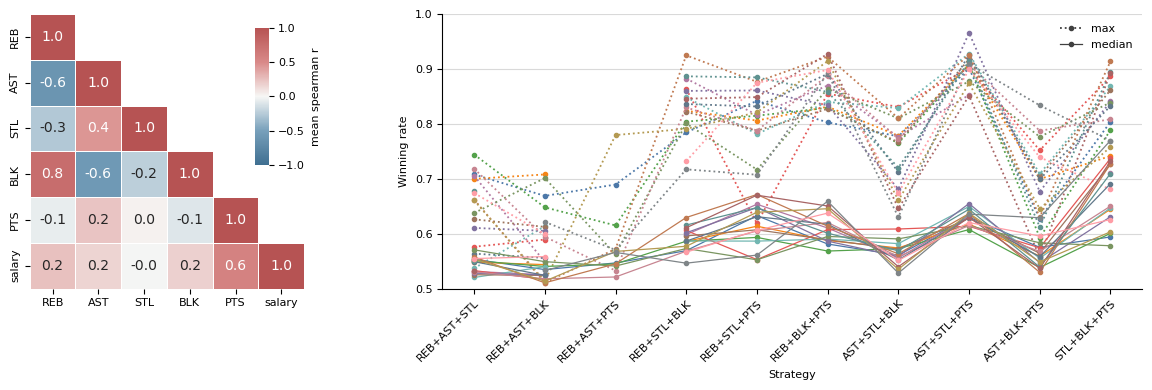

In [26]:
# final figure

from matplotlib.colors import LinearSegmentedColormap
plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,
})
# cmap_hm = LinearSegmentedColormap.from_list(
#     "paper_diverging",
#     ["#4C78A8", "#F7F7F7", "#E45756"]
# )
cmap_hm = LinearSegmentedColormap.from_list(
    "paper_diverging",
    [
        "#3F6F91",  # muted dark blue
        "#78A0BB",  # soft blue
        "#F7F7F5",  # off-white
        "#D98988",  # soft red
        "#B65353",  # muted dark red
    ]
)
LINE_COLORS_20 = [
    "#4C78A8", "#F58518", "#54A24B", "#B279A2", "#E45756",
    "#72B7B2", "#9D755D", "#8172A0", "#7A9561", "#C78591",
    "#61788A", "#C07A52", "#5F9290", "#A86464", "#B49A52",
    "#7F8588", "#FF9DA6", "#806A58", "#EDC948", "#BAB0AC",
]
STAT_STYLES = {"max": (":", 1.3), "median": ("-", 0.9)}
stats = [("max", maxwr_summary), ("median", medianwr_summary)]
coalition_labels = coverage_summary.index
x = np.arange(len(coalition_labels), dtype=float)
fig, (ax_hm, ax_ln) = plt.subplots(
    1, 2,
    figsize=(12, 4),                      # 3 + 8 wide, 3 tall
    gridspec_kw={"width_ratios": [4, 8]}, # keep each panel's original width
)
# --- left: correlation heatmap (original 3×3) ---
HEATMAP_LABELS = [c if c != "TRB" else "REB" for c in COLUMNS]
mask = np.triu(np.ones_like(mean_mat, dtype=bool), k=1)
sns.heatmap(
    pd.DataFrame(mean_mat, index=HEATMAP_LABELS, columns=HEATMAP_LABELS),
    mask=mask, cmap=cmap_hm, vmin=-1, vmax=1, center=0,
    annot=True, fmt=".1f", square=True, linewidths=.5, cbar=False,
    # cbar_kws={"label": f"mean {CORR_METHOD} r across seasons", "shrink": .7},
    ax=ax_hm,
)
cax = ax_hm.inset_axes([0.82, 0.45, 0.05, 0.50])
cb = fig.colorbar(ax_hm.collections[0], cax=cax)
cb.set_label(f"mean {CORR_METHOD} r")
cb.outline.set_visible(False)
# --- right: win-rate lines (original 8×3) ---
for name, df in stats:
    ls, lw = STAT_STYLES[name]
    for k, yr in enumerate(df.columns):
        ax_ln.plot(
            x, df[yr].values,
            marker="o", ms=3, lw=lw, linestyle=ls,
            color=LINE_COLORS_20[k % len(LINE_COLORS_20)],
        )
for name, _ in stats:
    ax_ln.plot(
        [], [], color="0.25",
        linestyle=STAT_STYLES[name][0], lw=STAT_STYLES[name][1],
        marker="o", ms=3, label=name,
    )
ax_ln.spines["top"].set_visible(False)
ax_ln.spines["right"].set_visible(False)
ax_ln.grid(True, axis="y", color="0.85", linewidth=0.8, zorder=0)
ax_ln.set_xticks(x)
ax_ln.set_xticklabels(
    coalition_labels, rotation=45, ha="right", va="top", rotation_mode="anchor"
)
ax_ln.set_xlabel("Strategy")
ax_ln.set_ylabel("Winning rate")
ax_ln.set_ylim(0.5, 1)
ax_ln.legend(frameon=False, fontsize=8, loc="upper right")
plt.tight_layout(w_pad=3)
fig.savefig("figure_data.png", dpi=300, bbox_inches="tight")
